<a href="https://colab.research.google.com/github/K-K-0/MLP-Assignments/blob/main/W9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Import Agglomerative Clustering for hierarchical clustering
from sklearn.cluster import AgglomerativeClustering

# Import dendrogram and linkage for hierarchical visualization
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
np.random.seed(42)

## Dataset Creation

We generate synthetic data using `make_blobs()`.

This creates clusters using Gaussian distributions.

In [ ]:
# Generate synthetic dataset
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Display first few rows
df.head()

,Feature1,Feature2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196


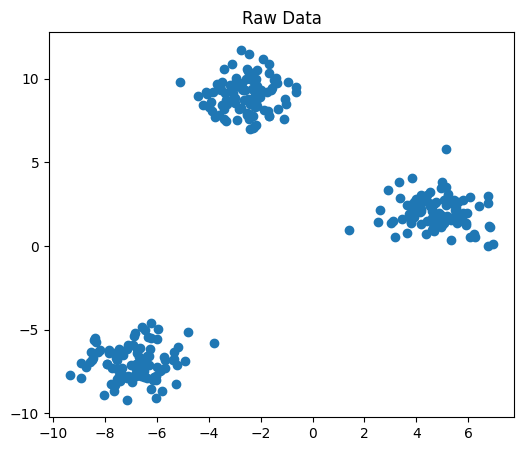

In [ ]:
# Plot raw data
plt.figure(figsize=(6,5))
plt.scatter(df['Feature1'], df['Feature2'])
plt.title("Raw Data")
plt.show()

K-Means Clustering

K-Means is a partition based clustering algorithm that divides the dataset into K clusters.

Algorithm Steps:
1. Initialize K centroids randomly
2. Assign each data point to nearest centroid
3. Recompute centroids
4. Repeat until convergence

Objective Function:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$
The goal is to minimize the distance between data points and their respective cluster centroids.

Advantages:
Simple and fast
Efficient for large datasets

Limitations:
Requires predefined K
Sensitive to initialization
Not suitable for non spherical clusters

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df)
labels = kmeans.predict(df)
df['KMeans_Cluster'] = labels

# Extract centroids
centroids = kmeans.cluster_centers_

In [ ]:
df.head()

,Feature1,Feature2,KMeans_Cluster,Hierarchical_Cluster
0,-7.338988,-7.729954,1,0
1,-7.740041,-7.264665,1,0
2,-1.686653,7.793442,0,2
3,4.422198,3.071947,2,1
4,-8.917752,-7.888196,1,0


In [ ]:
df['KMeans_Cluster']

,KMeans_Cluster
0,1
1,1
2,0
3,2
4,1
...,...
295,0
296,2
297,0
298,1


## Understanding Centroids Output

The centroids represent the center of each cluster in feature space.

Example Output:
```
[[-2.63,  9.04,  0]
 [-6.88, -6.98,  1]
 [ 4.74,  2.01,  2]]
```
### Interpretation
- Each row represents one cluster
- First two values correspond to Feature1 and Feature2
- The last value represents the cluster label index

Thus, each centroid defines the mean position of all data points belonging to that cluster.

In [ ]:
centroids

array([[-2.63323268,  9.04356978],
       [-6.88387179, -6.98398415],
       [ 4.74710337,  2.01059427]])

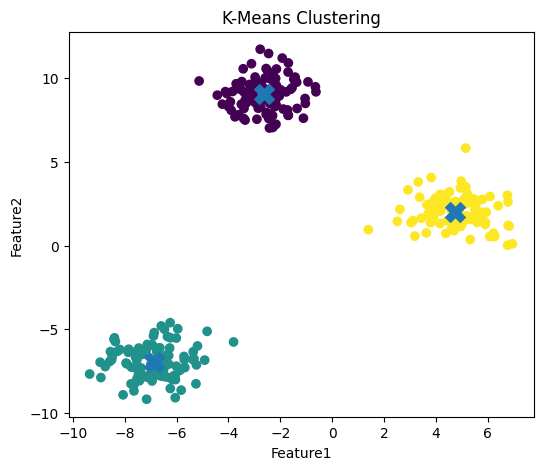

In [ ]:
plt.figure(figsize=(6,5))

# Plot data points with cluster colors
plt.scatter(df['Feature1'], df['Feature2'], c=df['KMeans_Cluster'], cmap='viridis')

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)

# Add labels and title
plt.title("K-Means Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

## Elbow Method

### Purpose
The Elbow Method helps determine the optimal number of clusters.

### Concept
- As K increases, inertia decreases
- At some point the decrease slows down significantly


### Interpretation
The optimal K is chosen where the curve bends sharply.

### Limitation
The elbow point is sometimes ambiguous.

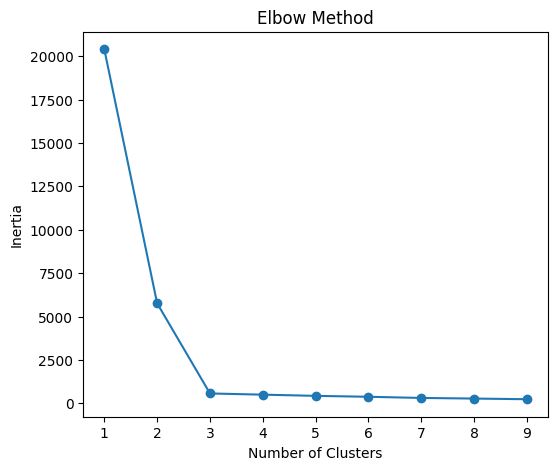

In [ ]:
# Store inertia values
inertia = []

# Define range of K
K_range = range(1, 10)

# Compute inertia for each K
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df[['Feature1','Feature2']])
    inertia.append(model.inertia_)

# Plot elbow curve
plt.figure(figsize=(6,5))
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

## Hierarchical Clustering

### Definition
Hierarchical clustering builds a hierarchy of clusters.

### Types
- Agglomerative (bottom up)
- Divisive (top down)

### Agglomerative Approach
- Each point starts as a cluster
- Closest clusters are merged iteratively

### What is Linkage?
Linkage is a method used to measure the distance between clusters during the merging process.

### Types of Linkage Methods

Single Linkage:
Distance between two clusters is the minimum distance between any two points from each cluster.

Complete Linkage:
Distance between clusters is the maximum distance between any two points from each cluster.

Average Linkage:
Distance is the average of all pairwise distances between points in two clusters.

Ward Linkage:
Minimizes the total within cluster variance. It merges clusters in a way that increases variance the least.

### Advantages
- No need to specify number of clusters initially
- Produces dendrogram for interpretation

### Disadvantages
- Computationally expensive

In [ ]:
# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)

# Predict cluster labels
h_labels = hc.fit_predict(df[['Feature1','Feature2']])

# Store results
df['Hierarchical_Cluster'] = h_labels

In [ ]:
sum(df['KMeans_Cluster']==df["Hierarchical_Cluster"])

0

In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['KMeans_Cluster'], df['Hierarchical_Cluster'])
print("ARI:", ari)

ARI: 1.0


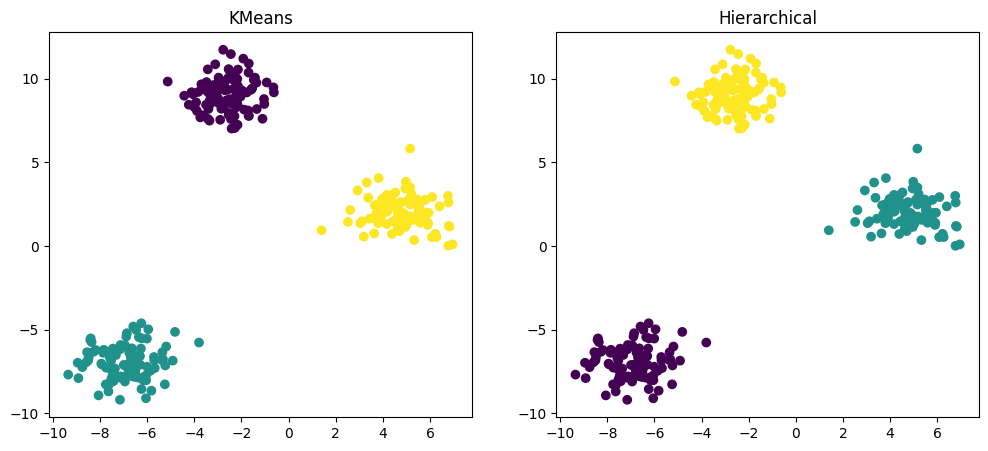

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df['Feature1'], df['Feature2'], c=df['KMeans_Cluster'])
plt.title("KMeans")

plt.subplot(1,2,2)
plt.scatter(df['Feature1'], df['Feature2'], c=df['Hierarchical_Cluster'])
plt.title("Hierarchical")

plt.show()

In [ ]:
df['KMeans_Cluster']

,KMeans_Cluster
0,1
1,1
2,0
3,2
4,1
...,...
295,0
296,2
297,0
298,1


In [ ]:
df['Hierarchical_Cluster']

,Hierarchical_Cluster
0,0
1,0
2,2
3,1
4,0
...,...
295,2
296,1
297,2
298,0


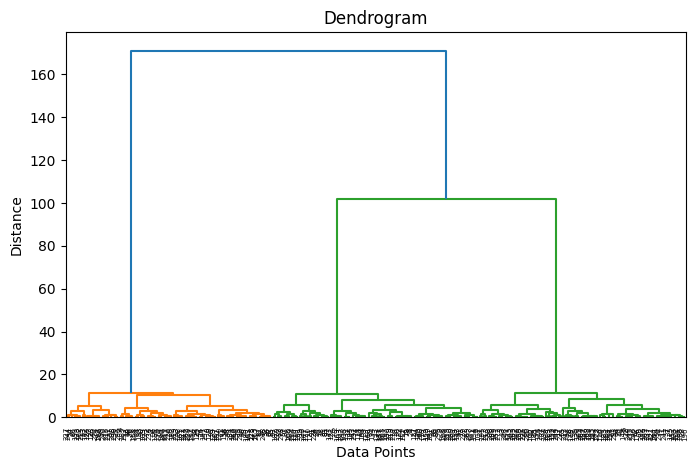

In [ ]:
# Compute linkage matrix
linked = linkage(df[['Feature1','Feature2']], method='ward')

# Plot dendrogram
plt.figure(figsize=(8,5))
dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

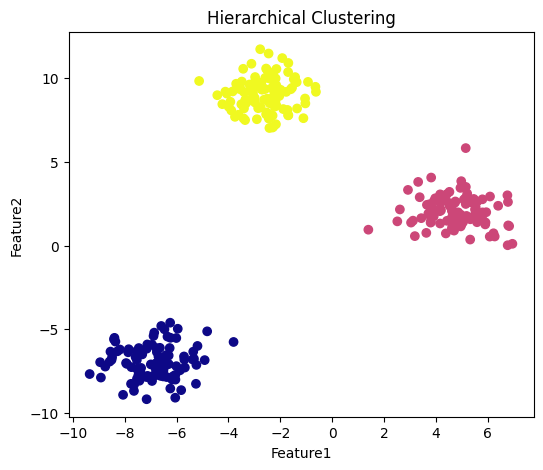

In [ ]:
# Plot hierarchical clustering results
plt.figure(figsize=(6,5))
plt.scatter(df['Feature1'], df['Feature2'], c=df['Hierarchical_Cluster'], cmap='plasma')

plt.title("Hierarchical Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

## Difference Between Agglomerative and Divisive Clustering

Hierarchical clustering can be divided into two main approaches: agglomerative and divisive.

### Agglomerative Clustering (Bottom-Up Approach)
- Starts with each data point as an individual cluster
- Iteratively merges the closest clusters
- Continues until all points are merged into a single cluster or desired number of clusters is reached

### Divisive Clustering (Top-Down Approach)
- Starts with all data points in a single cluster
- Recursively splits clusters into smaller clusters
- Continues until each point becomes its own cluster or stopping condition is met

### Key Differences

| Aspect | Agglomerative | Divisive |
|-------|--------------|----------|
| Approach | Bottom-up | Top-down |
| Initial State | n clusters (each point) | 1 cluster (all points) |
| Operation | Merge clusters | Split clusters |
| Complexity | Lower | Higher |
| Usage | More common | Less commonly used |

### Summary
Agglomerative clustering builds clusters by merging, while divisive clustering breaks clusters by splitting.

Data Visualization

Visualization helps interpret clustering results.

Objectives:
* Identify cluster separation
* Detect overlapping clusters
* Validate clustering performance

Types of visualizations used:
* Pairplot
* Heatmap
* Countplot
* Scatter plot

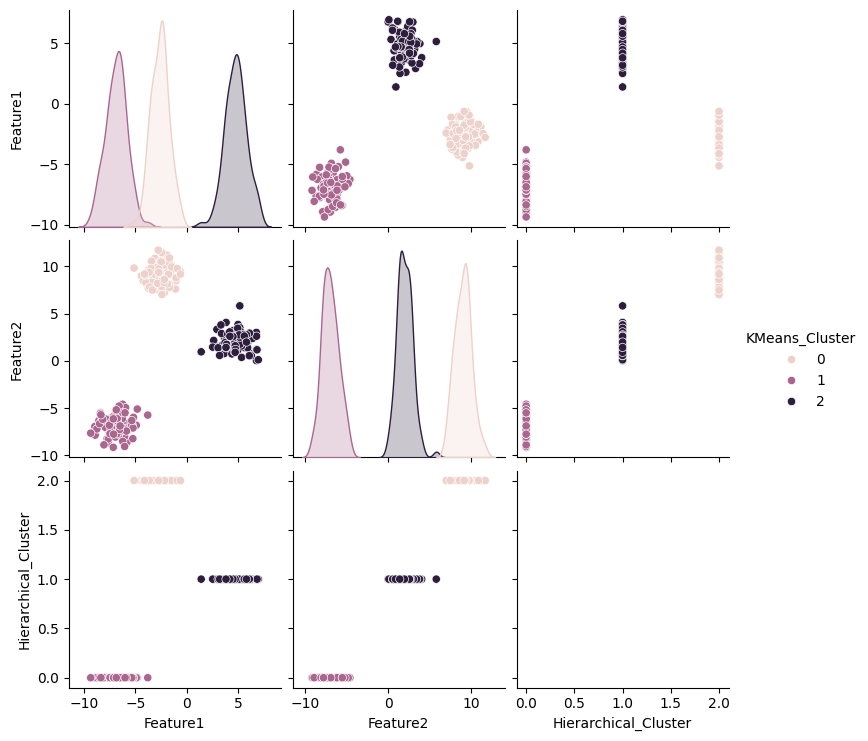

In [ ]:
# Pairplot visualization
sns.pairplot(df, hue='KMeans_Cluster')
plt.show()

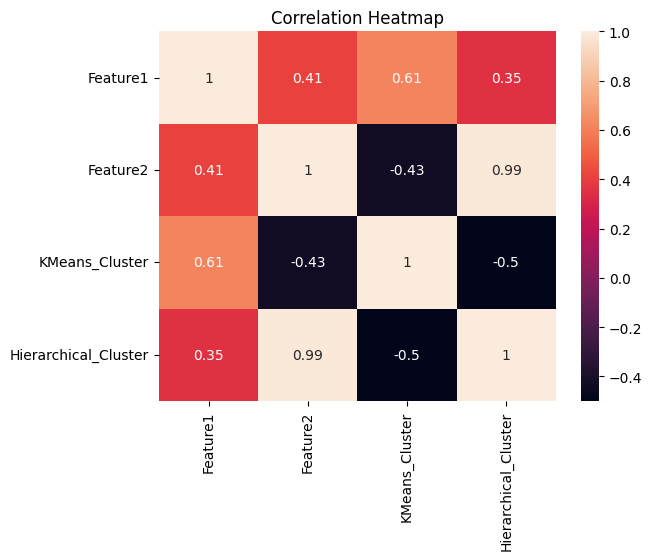

In [ ]:
# Correlation heatmap
corr = df.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")

plt.show()

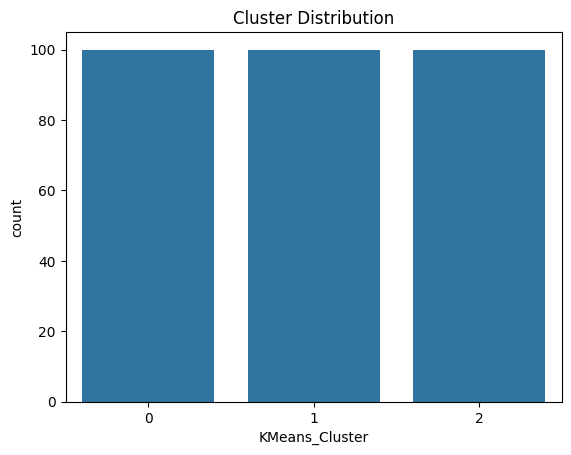

In [ ]:
# Cluster distribution plot
sns.countplot(x='KMeans_Cluster', data=df)

plt.title("Cluster Distribution")

plt.show()

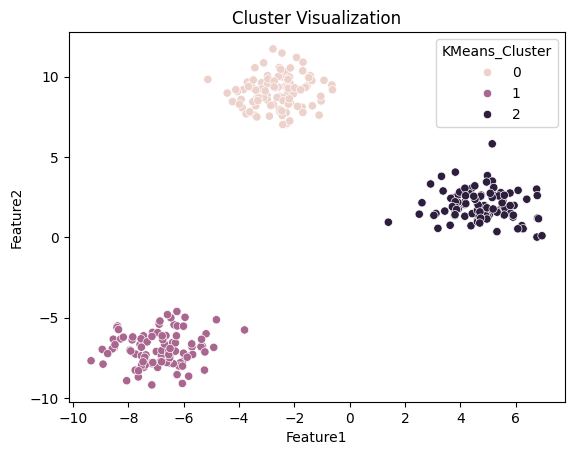

In [ ]:
# Scatter plot with cluster coloring
sns.scatterplot(x='Feature1', y='Feature2', hue='KMeans_Cluster', data=df)

plt.title("Cluster Visualization")

plt.show()